# 4.44 Every Coupling from One Eigenmode

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs%2Ftut%2F4-Analysis%2F4.44-Every-coupling-from-one-eigenmode.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2F4.44-Every-coupling-from-one-eigenmode.ipynb)

> 💡 **What you need.** gmsh, scikit-fem and SciPy (`pip install "quantum-metal[mesh]" scikit-fem pymetis`). About 6 minutes and up to 8 GB of memory in total; set `FINE = False` to skip the finest mesh. Fourth of five notebooks reproducing Molavi *et al.* [1]; [4.43](4.43-Mesh-and-solve-the-10x10-processor.ipynb) built the model.

A 100-qubit processor has 100 couplings to each package mode. Extracting them one qubit at a time — an avoided crossing per qubit, or an energy-participation solve per qubit — means 100 simulations per mode. The induced-EMF method needs one.

Open every junction. With nothing to carry current across its gap, each qubit mode drops to zero frequency, and near 6.5 GHz the eigensolver finds only the package mode. That mode's electric field reaches across every junction gap and induces a voltage there. Circuit theory (the paper's Appendix C, notebook 4.42) turns each voltage into a coupling,

$$g_n = \frac{\omega_m V_{n,\rm open}}{2}\sqrt{\frac{C_n + C_c}{2E_m}},$$

where $C_n + C_c$ is the capacitance across junction $n$. One eigenmode, one line integral per junction, one electrostatic capacitance per qubit.

**What you'll learn**

- how to extract all 100 couplings of the 10 × 10 array from a single full-wave solution (the paper's Fig. 6);
- how the couplings follow $A\cos(\pi x/L_x)\sin(\pi y/L_y)$, and what sets $A$ (Fig. 8);
- how mirror symmetry cuts the problem to a quarter, converges the answer, and separates degenerate modes (Fig. 9).

In [1]:
# In Colab, uncomment to install the dependencies of the whole series.
# !pip install -q "quantum-metal[mesh]" scikit-fem pymetis

In [2]:
import sys
import urllib.request
from pathlib import Path

# The solver code shared by tutorials 4.41-4.45 lives in docs/tut/resources/package_modes/.
RES = Path("../resources/package_modes")
if not (RES / "package_modes.py").exists():  # e.g. in Colab: fetch it next to the notebook
    RES = Path("package_modes")
    RES.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
        "docs/tut/resources/package_modes/package_modes.py", RES / "package_modes.py")
sys.path.insert(0, str(RES))

import package_modes as pm

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

FINE = True  # also run the finest quarter mesh (about 2 minutes, 6 GB)
P = pm.PAPER
design = pm.build_design()
package = pm.package_from_design(design)

## 1. The capacitance of every qubit

Electrostatics on a quarter of the package gives the capacitance across each junction (notebook 4.43 explains the calculation). By the mirror symmetry of the box and the array, the other three quarters repeat it.

In [3]:
start = time.time()
quarter = pm.mesh_package(package, region="quarter", h_metal=0.07, h_max=0.7)
es = pm.Electrostatics(quarter)
C_q = {(i, j): es.port_capacitance(f"Q_{i}_{j}.pad_left", f"Q_{i}_{j}.pad_right") for i in range(5) for j in range(5)}
C_all = pm.unfold_quarter(C_q, cuts=("pec", "pmc"))  # capacitance is even under both mirrors
print(f"C across the junction: {np.nanmin(C_all) * 1e15:.1f} - {np.nanmax(C_all) * 1e15:.1f} fF"
      f" ({time.time() - start:.0f} s)")

C across the junction: 173.5 - 174.3 fF (62 s)


## 2. One eigenmode of the full 10 × 10 box

The whole package, all 100 qubits, every junction open. One factorization and one eigenvalue, then a signed sum of edge values across each of the 100 junction gaps.

In [4]:
start = time.time()
full = pm.mesh_package(package, region="full", h_metal=0.1, h_max=1.0)
fem = pm.MaxwellFEM(full)
(mode,) = fem.eigenmodes(6.5e9)
print(f"{full.summary()}\n{fem.n_dofs:,} unknowns; package mode at {mode.f / 1e9:.4f} GHz ({time.time() - start:.0f} s)")

g_full = np.zeros((10, 10))
V_full = np.zeros((10, 10))
for name in package.junctions:
    i, j = pm.Package.qubit_index(name)
    V_full[j, i] = mode.voltage(name)
    g_full[j, i] = pm.emf_coupling(mode.f, V_full[j, i], C_all[j, i])
print(f"junction voltages for 1 J: {np.abs(V_full).min():.0f} to {np.abs(V_full).max():.0f} V")
fem._factors.clear()  # free the factorization; the mode and its field stay available

full package: 436,185 tetrahedra, 80,950 nodes, 200 paddles, 100 junctions (meshed in 3.8 s)
453,657 unknowns; package mode at 6.4862 GHz (37 s)
junction voltages for 1 J: 139 to 15598 V


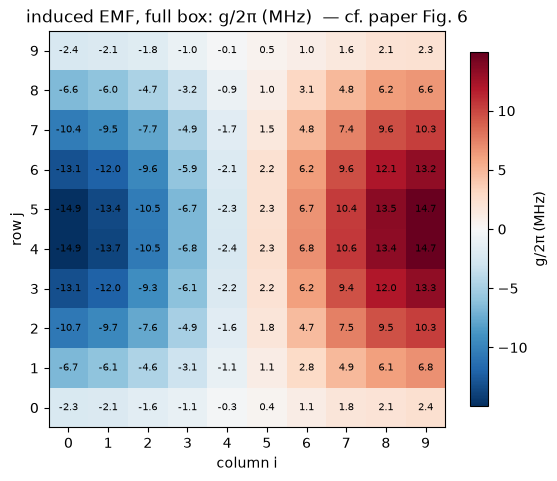

In [5]:
def coupling_map(g, title, ax=None):
    ax = ax or plt.subplots(figsize=(6.4, 5.4))[1]
    lim = np.nanmax(np.abs(g)) / 1e6
    im = ax.imshow(g / 1e6, origin="lower", cmap="RdBu_r", vmin=-lim, vmax=lim)
    for j in range(g.shape[0]):
        for i in range(g.shape[1]):
            ax.text(i, j, f"{g[j, i] / 1e6:.1f}", ha="center", va="center", fontsize=7)
    ax.set(xlabel="column i", ylabel="row j", xticks=range(10), yticks=range(10), title=title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="g/2π (MHz)")
    return ax


coupling_map(g_full, "induced EMF, full box: g/2π (MHz)  — cf. paper Fig. 6")
plt.show()

The same 100 numbers on the chip itself — each paddle pair colored by its qubit's coupling to the package mode:

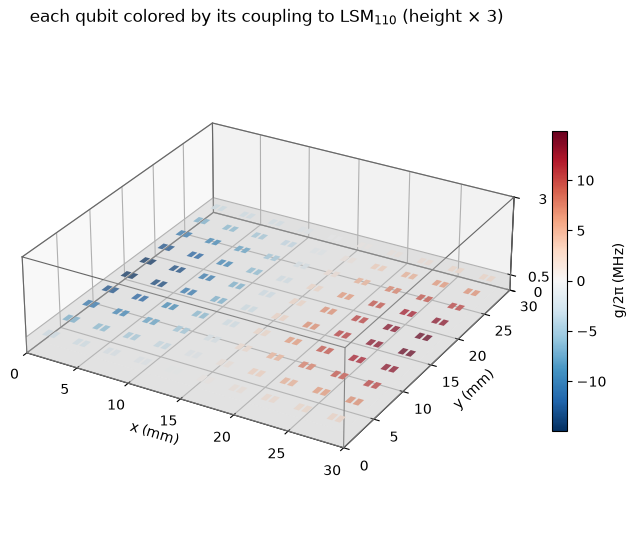

In [6]:
from matplotlib import cm, colors as mcolors

norm = mcolors.TwoSlopeNorm(vmin=-np.abs(g_full).max(), vcenter=0, vmax=np.abs(g_full).max())
pad_colors = []
for name in package.metals:
    i, j = pm.Package.qubit_index(name.split(".")[0])
    pad_colors.append(cm.RdBu_r(norm(g_full[j, i])))
fig = plt.figure(figsize=(9, 6.5))
ax3 = fig.add_subplot(projection="3d")
pm.plot_package_3d(ax3, package, colors=pad_colors)
fig.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(-np.abs(g_full).max() / 1e6, np.abs(g_full).max() / 1e6), cmap="RdBu_r"),
             ax=ax3, shrink=0.6, label="g/2π (MHz)")
ax3.set_title("each qubit colored by its coupling to LSM$_{110}$ (height × 3)")
plt.show()

The coupling map of the paper's Fig. 6: antisymmetric about the middle column, symmetric about the middle row, largest in the outer columns and middle rows. The overall sign is a convention (the sign of the eigenvector); the relative signs between qubits are physical — a qubit in column 0 and one in column 9 couple to this mode with opposite signs.

The mesh is not symmetric, so the mirror symmetry of the result is a check on the discretization. The paper sees the same small deviations (compare its qubits (0,0) and (9,0)).

In [7]:
anti_x = np.abs(g_full + g_full[:, ::-1]) / np.abs(g_full).max()
sym_y = np.abs(g_full - g_full[::-1, :]) / np.abs(g_full).max()
print(f"largest deviation from the mirror symmetries: {anti_x.max():.2%} (x), {sym_y.max():.2%} (y) of max|g|")
print(f"qubit (0,0): {g_full[0, 0] / 1e6:+.3f} MHz,  qubit (9,0): {g_full[0, 9] / 1e6:+.3f} MHz")

largest deviation from the mirror symmetries: 2.31% (x), 2.11% (y) of max|g|
qubit (0,0): -2.322 MHz,  qubit (9,0): +2.360 MHz


## 3. One amplitude for all 100 qubits (Fig. 8)

Plotting the couplings against the qubit's position $x/L_x$ row by row exposes the pattern predicted in notebook 4.41: each row is a cosine in $x$, and the rows scale as $\sin(\pi y/L_y)$. One number fits all of them,

$$g = A\cos(\pi x/L_x)\sin(\pi y/L_y).$$

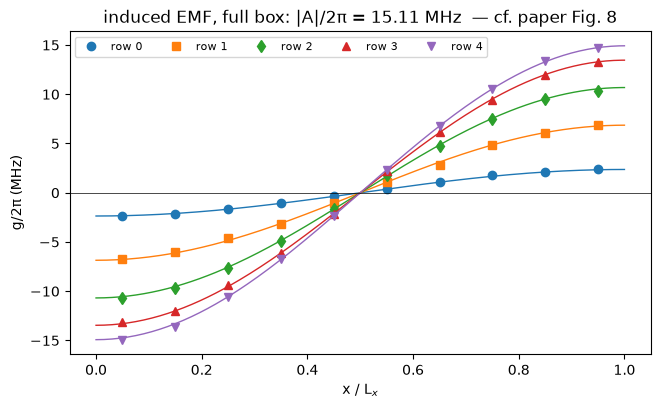

|A|/2pi = 15.11 MHz, largest misfit 2.4% of |A|   (paper: 15.6 MHz)


In [8]:
A_full, resid = pm.fit_amplitude(g_full)
centers = pm.qubit_centers()
xs = np.array([centers[(i, 0)][0] for i in range(10)]) / 30
xx = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, marker in zip(range(5), "osd^v"):
    y = centers[(0, j)][1]
    line, = ax.plot(xx, A_full * np.cos(np.pi * xx) * np.sin(np.pi * y / 30) / 1e6, lw=1)
    ax.plot(xs, g_full[j] / 1e6, marker, color=line.get_color(), label=f"row {j}")
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="x / L$_x$", ylabel="g/2π (MHz)", title=f"induced EMF, full box: |A|/2π = {abs(A_full) / 1e6:.2f} MHz  — cf. paper Fig. 8")
ax.legend(fontsize=8, ncol=5)
plt.show()
print(f"|A|/2pi = {abs(A_full) / 1e6:.2f} MHz, largest misfit {resid:.1%} of |A|   (paper: {P['A_110'] / 1e6:.1f} MHz)")

## 4. Symmetry: a quarter of the work, and convergence

The full box above uses 0.1 mm elements at the paddle edges. Converging the couplings means refining there, and the full box gets expensive quickly. Symmetry helps. The box and the array are unchanged by the mirrors $x \to L_x - x$ and $y \to L_y - y$, so every mode is either even or odd under each. The LSM$_{110}$ mode has $E_x$ odd and $E_y$ even about $x = L_x/2$ — its field is tangential to that plane — and likewise about $y = L_y/2$. A perfect *magnetic* conductor (PMC) enforces exactly that, and in the edge-element formulation it costs nothing: it is the natural boundary condition, the one you get by leaving the cut face alone.

So a quarter of the box, 25 qubits, and two PMC walls reproduce the mode. The mode energy is four times that of the quarter — `pm.MaxwellFEM` accounts for it — and the other 75 couplings follow by symmetry.

In [9]:
def quarter_couplings(h_metal, h_max, cuts=("pmc", "pmc"), f_guess=6.5e9):
    start = time.time()
    m = pm.mesh_package(package, region="quarter", h_metal=h_metal, h_max=h_max)
    fem_q = pm.MaxwellFEM(m, cuts=cuts)
    (mq,) = fem_q.eigenmodes(f_guess)
    g = {}
    for name in m.junction_segs:
        i, j = pm.Package.qubit_index(name)
        g[(i, j)] = pm.emf_coupling(mq.f, mq.voltage(name), C_q[(i, j)])
    info = f"{fem_q.n_dofs:,} unknowns, {time.time() - start:.0f} s"
    fem_q._factors.clear()
    return mq, pm.unfold_quarter(g, cuts), info


meshes = [(0.15, 1.0), (0.1, 1.0), (0.07, 1.0)] + ([(0.05, 1.0)] if FINE else [])
convergence = []
for h_metal, h_max in meshes:
    mode_q, g, info = quarter_couplings(h_metal, h_max)
    f = mode_q.f
    A, resid = pm.fit_amplitude(g)
    convergence.append((h_metal, f, A, g))
    print(f"h_metal = {h_metal:.2f} mm: f = {f / 1e9:.4f} GHz, |A|/2pi = {abs(A) / 1e6:.2f} MHz,"
          f" misfit {resid:.1%}  ({info})")
print(f"\nfull box at h_metal = 0.10 mm, for comparison: |A|/2pi = {abs(A_full) / 1e6:.2f} MHz")

h_metal = 0.15 mm: f = 6.4852 GHz, |A|/2pi = 14.87 MHz, misfit 1.6%  (70,523 unknowns, 4 s)


h_metal = 0.10 mm: f = 6.4862 GHz, |A|/2pi = 14.92 MHz, misfit 2.1%  (113,939 unknowns, 7 s)


h_metal = 0.07 mm: f = 6.4870 GHz, |A|/2pi = 15.49 MHz, misfit 0.5%  (186,304 unknowns, 12 s)


h_metal = 0.05 mm: f = 6.4873 GHz, |A|/2pi = 15.63 MHz, misfit 0.6%  (276,768 unknowns, 20 s)

full box at h_metal = 0.10 mm, for comparison: |A|/2pi = 15.11 MHz


The quarter model at 0.1 mm reproduces the full box, and refining the paddle edges raises $|A|$ toward the paper's 15.6 MHz. What moves with refinement is the field in the junction gap: coarse elements cannot follow the charge that crowds onto the facing paddle edges (notebook 4.43), and they underestimate the voltage across the gap. That also points to the cheapest refinement: `pm.mesh_package(..., h_junction=0.05)` seeds only a small sphere around each junction and moves $|A|$ as much as halving the element size everywhere on the paddles.

The converged map, unfolded from the finest quarter:

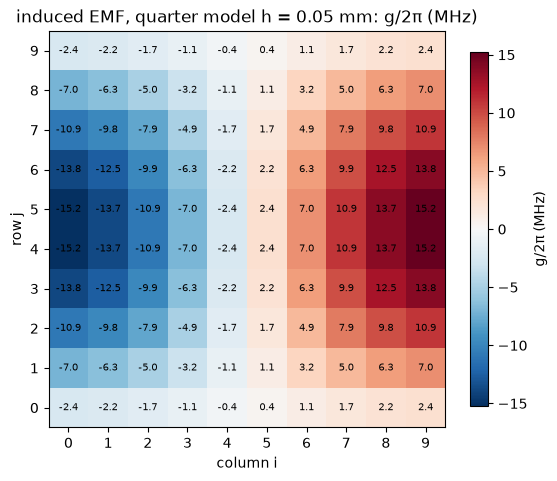

In [10]:
g_best = convergence[-1][3]
coupling_map(g_best, f"induced EMF, quarter model h = {convergence[-1][0]} mm: g/2π (MHz)")
plt.show()

## 5. The second mode, LSM$_{210}$ (Fig. 9)

In a square box, LSM$_{210}$ and LSM$_{120}$ are degenerate. The paper stretches the box to $L_x = 30.2$ mm to pull them apart. Symmetry separates them without touching the geometry: LSM$_{210}$ has $E_z \propto \sin(2\pi x/L_x)$, odd about the middle plane $x = L_x/2$, so its field there is *normal* to the plane — a perfect electric conductor (PEC). LSM$_{120}$ is even about that plane, so a quarter model with a PEC wall at $x = L_x/2$ and a PMC wall at $y = L_y/2$ holds LSM$_{210}$ and not its twin.

LSM210: f = 10.218 GHz  (paper, without paddles: 10.23 GHz)  (275,733 unknowns, 21 s)
|A_210|/2pi = 51.6 MHz, misfit 0.5%   (paper: 49.8 MHz)


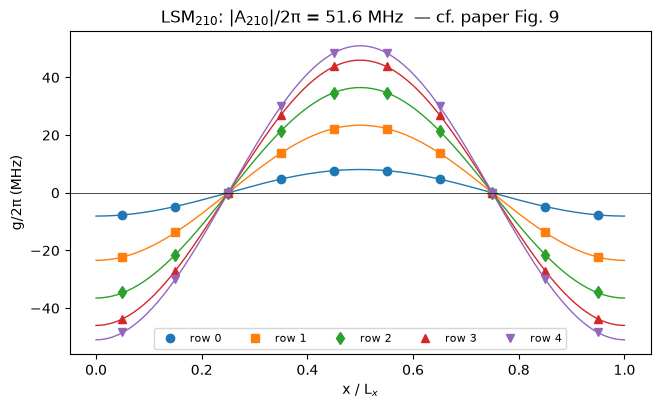

In [11]:
h210 = convergence[-1][0]
mode210, g210, info = quarter_couplings(h210, 1.0, cuts=("pec", "pmc"), f_guess=10.2e9)
f210 = mode210.f
A210, resid210 = pm.fit_amplitude(g210, a=2)
print(f"LSM210: f = {f210 / 1e9:.3f} GHz  (paper, without paddles: {P['f_lsm210'] / 1e9:.2f} GHz)  ({info})")
print(f"|A_210|/2pi = {abs(A210) / 1e6:.1f} MHz, misfit {resid210:.1%}   (paper: {P['A_210'] / 1e6:.1f} MHz)")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, marker in zip(range(5), "osd^v"):
    y = centers[(0, j)][1]
    line, = ax.plot(xx, A210 * np.cos(2 * np.pi * xx) * np.sin(np.pi * y / 30) / 1e6, lw=1)
    ax.plot(xs, g210[j] / 1e6, marker, color=line.get_color(), label=f"row {j}")
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="x / L$_x$", ylabel="g/2π (MHz)", title=f"LSM$_{{210}}$: |A$_{{210}}$|/2π = {abs(A210) / 1e6:.1f} MHz  — cf. paper Fig. 9")
ax.legend(fontsize=8, ncol=5)
plt.show()

The two modes side by side. Each quarter solution fills the whole box by its symmetry: $E_z$ is even across a PMC plane and odd across a PEC plane. The in-plane field at the silicon surface is what the qubits feel — one sign change across the box for LSM$_{110}$, two for LSM$_{210}$.

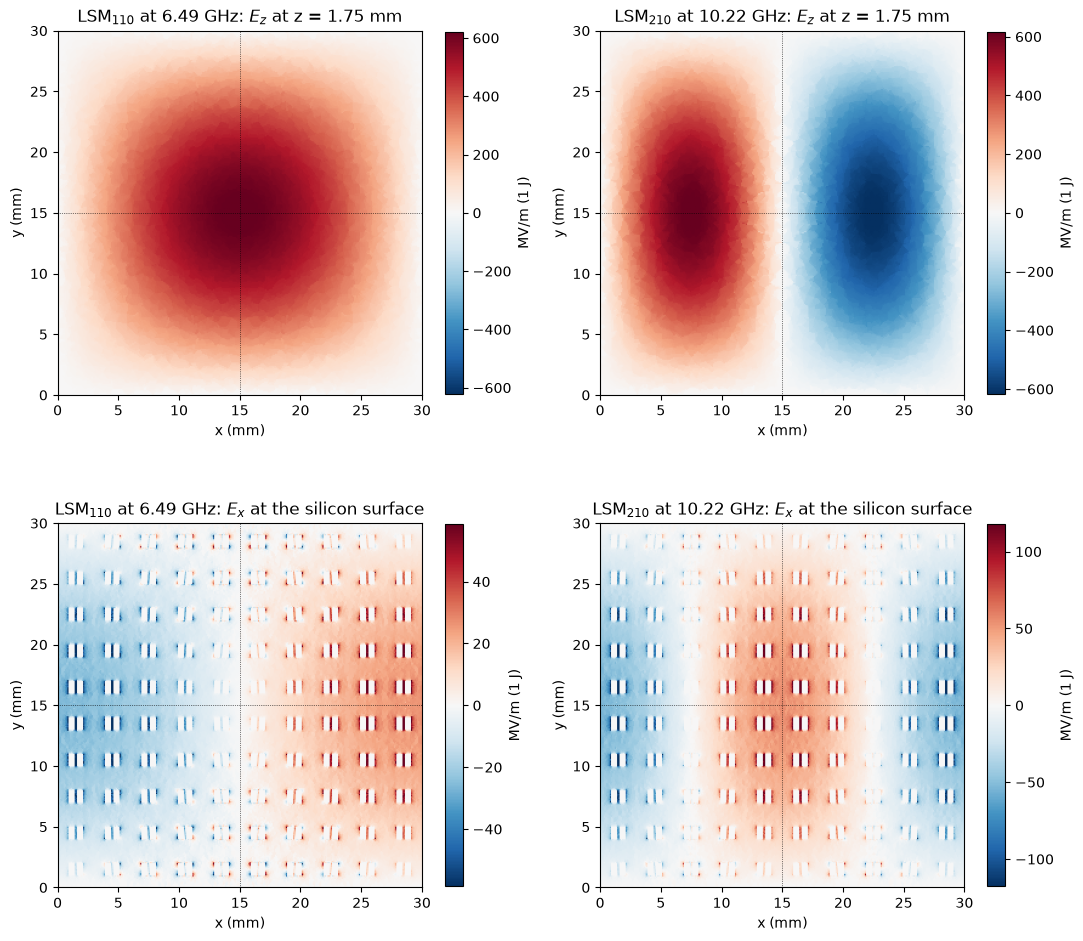

In [12]:
def unfold_field(values, cuts, parity):
    """Mirror a quarter-grid field (rows y, cols x) to the whole box. parity: +1 even, -1 odd per cut."""
    px, py = parity
    right = np.hstack([values, px * values[:, ::-1]])
    return np.vstack([right, py * right[::-1, :]])


xq = np.linspace(0.05, 14.95, 150)
Xq, Yq = np.meshgrid(xq, xq)
fig, ax = plt.subplots(2, 2, figsize=(11, 10))
for col, (m, name, cuts) in enumerate(((mode_q, "LSM$_{110}$", ("pmc", "pmc")), (mode210, "LSM$_{210}$", ("pec", "pmc")))):
    ez = m.field(np.vstack([Xq.ravel(), Yq.ravel(), np.full(Xq.size, 1.75)]))[2].reshape(Xq.shape) / 1e6
    ex = m.field(np.vstack([Xq.ravel(), Yq.ravel(), np.full(Xq.size, package.t + 1e-6)]))[0].reshape(Xq.shape) / 1e6
    ez_parity = (+1 if cuts[0] == "pmc" else -1, +1 if cuts[1] == "pmc" else -1)
    ex_parity = (-ez_parity[0], ez_parity[1])  # E_x flips relative to E_z across the x-cut
    for row, (F, par, label) in enumerate(((ez, ez_parity, "$E_z$ at z = 1.75 mm"), (ex, ex_parity, "$E_x$ at the silicon surface"))):
        full_F = unfold_field(F, cuts, par)
        lim = np.percentile(np.abs(full_F), 99.5)
        im = ax[row, col].imshow(full_F, origin="lower", extent=(0, 30, 0, 30), cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax[row, col].axvline(15, color="k", lw=0.5, ls=":"); ax[row, col].axhline(15, color="k", lw=0.5, ls=":")
        ax[row, col].set(title=f"{name} at {m.f / 1e9:.2f} GHz: {label}", xlabel="x (mm)", ylabel="y (mm)")
        plt.colorbar(im, ax=ax[row, col], shrink=0.8, label="MV/m (1 J)")
plt.tight_layout()
plt.show()

## 6. Full wave against the dipole picture

Notebook 4.41 predicted both amplitudes from a single physical picture — a qubit dipole in the in-plane field of the mode — and notebook 4.43 computed the dipole moment from electrostatics. The comparison:

In [13]:
px = abs(es.dipole("Q_0_0.pad_left", "Q_0_0.pad_right")[0])
A_best = convergence[-1][2]
rows = []
for label, mode_ab, A_fem, A_paper in (("LSM110", pm.lsm_mode(1, 1), A_best, P["A_110"]),
                                        ("LSM210", pm.lsm_mode(2, 1), A210, P["A_210"])):
    _, A_ours = pm.dipole_coupling(px, mode_ab)
    _, A_theirs = pm.dipole_coupling(P["px"], mode_ab)
    rows.append((label, abs(A_fem), A_paper, A_ours, A_theirs))
print(f"{'':>7} {'full wave':>10} {'paper':>7} {'dipole, our p_x':>16} {'dipole, paper p_x':>18}   (MHz)")
for label, a, b, c, d in rows:
    print(f"{label:>7} {a / 1e6:10.1f} {b / 1e6:7.1f} {c / 1e6:16.1f} {d / 1e6:18.1f}")
print(f"\nratio A_210 / A_110: full wave {abs(A210 / A_best):.2f} (paper {P['A_210'] / P['A_110']:.2f});"
      f" 2 w_210 / w_110 = {2 * f210 / convergence[-1][1]:.2f}")

         full wave   paper  dipole, our p_x  dipole, paper p_x   (MHz)
 LSM110       15.6    15.6             15.7               14.1
 LSM210       51.6    49.8             50.9               45.8

ratio A_210 / A_110: full wave 3.30 (paper 3.19); 2 w_210 / w_110 = 3.15


The electric-dipole picture captures the pattern, the ratio between the two modes, and — within the spread of the dipole moment — the size of the couplings. The magnetic coupling it leaves out is small; the paper estimates that only about 4% of a transmon's energy is magnetic.

## Summary

| | This notebook | Paper |
|---|---|---|
| method | induced EMF, gmsh + scikit-fem | induced EMF, HFSS |
| coupling pattern | $A\cos(\pi x/L_x)\sin(\pi y/L_y)$ for all 100 qubits | same |
| $\lvert A\rvert/2\pi$, LSM$_{110}$ | ≈ 15.6 MHz (finest quarter mesh) | 15.6 MHz |
| $\lvert A_{210}\rvert/2\pi$, LSM$_{210}$ | ≈ 52 MHz | 49.8 MHz |
| ratio $A_{210}/A_{110}$ | ≈ 3.3 | 3.19 |

## Where to go next

- **4.45 Four methods, one full-wave model** — avoided crossing, energy participation and the impedance matrix, on the same finite-element model, against the induced EMF of this notebook (the paper's Figs. 5 and 7).
- Rotate every qubit by 90° with `pm.build_design(orientation=90)` and re-run Sec. 2 on the full box: the dipoles then point along $y$, and the pattern turns into $\sin(\pi x/L_x)\cos(\pi y/L_y)$.
- Stretch the box as the paper does, `pm.build_design(Lx=30.2)`, and find LSM$_{210}$ and LSM$_{120}$ at separate frequencies in the full box.

## References

1. R. Molavi, E. Forati, Y. Zhang, A. R. Klots, J. Atalaya, B. W. Langley, D. A. Timucin, M. Nazari, G. Khan, Z. K. Minev, A. N. Korotkov, M. H. Devoret, "Extracting electromagnetic bare mode couplings in large superconducting quantum processors," [arXiv:2609.22442](https://arxiv.org/abs/2609.22442) (2026).
2. Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, M. H. Devoret, "Energy-participation quantization of Josephson circuits," *npj Quantum Inf.* **7**, 131 (2021). [doi:10.1038/s41534-021-00461-8](https://doi.org/10.1038/s41534-021-00461-8)
3. C. A. Balanis, *Advanced Engineering Electromagnetics*, 2nd ed. (Wiley, 2012) — LSM modes of a partially filled waveguide.
4. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
5. T. Gustafsson, G. D. McBain, "scikit-fem: A Python package for finite element assembly," *J. Open Source Softw.* **5**, 2369 (2020). [doi:10.21105/joss.02369](https://doi.org/10.21105/joss.02369)